#Um projeto sobre a frota de carros elétricos nos Estados Unidos.
-
-

In [95]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

In [96]:
df = pd.read_csv('/content/frota_carro_eletricos_eua.csv', encoding= 'latin-1')

In [97]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294193 entries, 0 to 294192
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         294193 non-null  object 
 1   County                                             294183 non-null  object 
 2   City                                               294183 non-null  object 
 3   State                                              294193 non-null  object 
 4   Postal Code                                        294183 non-null  float64
 5   Model Year                                         294193 non-null  int64  
 6   Make                                               294193 non-null  object 
 7   Model                                              294193 non-null  object 
 8   Electric Vehicle Type                              294193 non-null  object

In [99]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 GEOID
count,294183.000000,294193.000000,294180.000000,293431.000000,2.941930e+05,2.941830e+05
mean,98176.263231,2022.312665,36.922578,28.766582,2.504942e+08,5.296843e+10
std,2644.315758,3.085205,76.309809,14.892012,6.244728e+07,1.674636e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.278658e+08,5.303301e+10
50%,98134.000000,2023.000000,0.000000,32.000000,2.675898e+08,5.303303e+10
75%,98390.000000,2024.000000,32.000000,42.000000,2.834127e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10



#AGEMC
- ASK
- GET
- EXPLORER
- MODEL
- COMUNICATE


# A missão do ciêntista de dados é:
- **Extrair conhecimento** de dados desorganizados.

# Perguntas:
  - Quais as cidades com mais veículos elétricos em Washington WA?

In [100]:
df.sample(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
160986,JN1DF0CD8P,King,Seattle,WA,98118.0,2023,NISSAN,ARIYA HATCHBACK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,237755633,POINT (-122.28083 47.54693),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303301e+10
246670,5YJXCAE20J,Island,Camano Island,WA,98282.0,2018,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,10.0,347503796,POINT (-122.40049 48.23986),BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,5.302997e+10
29288,7SAYGDEE8T,Benton,Kennewick,WA,99337.0,2026,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,8.0,285294383,POINT (-119.14482 46.18763),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...,5.300501e+10
282139,7SAYGDEE5S,Snohomish,Sultan,WA,98294.0,2025,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,39.0,287430104,POINT (-121.81688 47.8623),PUGET SOUND ENERGY INC,5.306105e+10
248174,7FCEHDB72N,Kitsap,Bremerton,WA,98312.0,2022,RIVIAN,EDV,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,35.0,219550299,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303509e+10


In [101]:
df.tail(4)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
294189,5YJ3E1EB3L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,14.0,292558003,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
294190,KNDCR3L13S,King,Seattle,WA,98118.0,2025,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,282972294,POINT (-122.28083 47.54693),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
294191,JTDKARFP0H,Pierce,Lakewood,WA,98499.0,2017,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,28.0,168423146,POINT (-122.51495 47.16196),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
294192,5YJ3E1EA6L,Snohomish,Bothell,WA,98021.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,1.0,137123871,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [102]:
np.ones(10)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [103]:
df.shape

(294193, 16)

In [104]:
# df.County.describe()[]

In [105]:
quantidade_linhas = df.shape[0]

In [106]:
df['Quantidade'] = np.ones(quantidade_linhas)

In [107]:
df['Model Year'].max()

2027

In [108]:
city_df = df.groupby("County").agg({
    "Model Year": "mean",
    "Quantidade": "sum"
    }).reset_index()

In [109]:
city_df.sample(10)

,County,Model Year,Quantidade
231,Summit,2020.000000,1.0
195,Riley,2023.000000,1.0
33,Camden,2023.000000,1.0
155,Montgomery,2022.307692,13.0
183,Placer,2021.333333,3.0
227,Stanislaus,2024.000000,1.0
150,Milwaukee,2024.000000,1.0
20,Benton,2021.958257,4384.0
248,Whatcom,2021.686965,7357.0
179,Penobscot,2012.000000,1.0


In [110]:
city_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   County      257 non-null    object 
 1   Model Year  257 non-null    float64
 2   Quantidade  257 non-null    float64
dtypes: float64(2), object(1)
memory usage: 6.2+ KB


In [111]:
city_df.describe()

,Model Year,Quantidade
count,257.000000,257.000000
mean,2021.971221,1144.680934
std,2.069723,9387.478251
min,2012.000000,1.000000
25%,2021.000000,1.000000
50%,2022.000000,2.000000
75%,2023.250000,6.000000
max,2026.000000,141971.000000


In [129]:
city_df.sort_values(by= 'Quantidade', ascending= True, inplace= True)

In [130]:
city_df = city_df.reset_index()

In [131]:
city_df.drop(columns= ['index'], inplace= True)

In [132]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 GEOID', 'Quantidade'],
      dtype='object')

In [133]:
city_df

,County,Model Year,Quantidade
0,Escambia,2023.000000,1.0
1,Creek,2024.000000,1.0
2,Curry,2025.000000,1.0
3,Cuyahoga,2024.000000,1.0
4,Dale,2023.000000,1.0
...,...,...,...
252,Thurston,2021.957246,10806.0
253,Clark,2022.275579,18365.0
254,Pierce,2022.279762,24578.0
255,Snohomish,2022.486560,37128.0


In [134]:
maior_frota = city_df.loc[247: 257].copy()

In [137]:
maior_frota.head(10)

,County,Model Year,Quantidade
247,Skagit,2021.925799,3504.0
248,Benton,2021.958257,4384.0
249,Whatcom,2021.686965,7357.0
250,Spokane,2022.291779,8503.0
251,Kitsap,2022.073834,10185.0
252,Thurston,2021.957246,10806.0
253,Clark,2022.275579,18365.0
254,Pierce,2022.279762,24578.0
255,Snohomish,2022.486560,37128.0
256,King,2022.458671,141971.0


In [136]:
sns.set_style('darkgrid')

In [156]:
list(maior_frota.County)[-1]

'King'

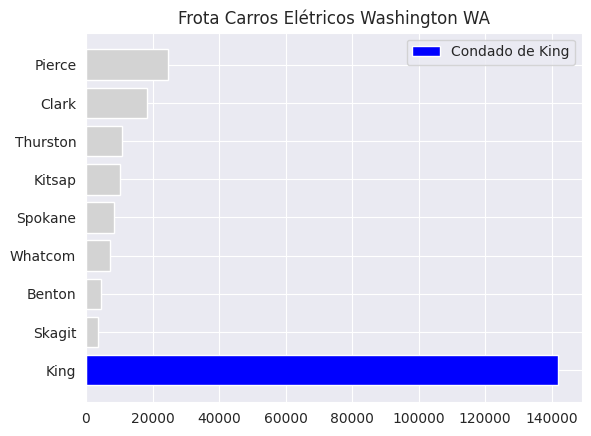

In [163]:
plt.barh(list(maior_frota.County)[-1], list(maior_frota.Quantidade)[-1], color= 'blue')
plt.barh(list(maior_frota.County)[:-2], list(maior_frota.Quantidade)[:-2], color= 'lightgray')
plt.title("Frota Carros Elétricos Washington WA")

plt.legend(["Condado de King"]);